<a href="https://colab.research.google.com/github/xMrTuffnut/ai-companion-wellbeing/blob/main/notebooks/05_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final results
**Assembled at the end from everyone's results**

Rules: only the owner edits this notebook. Before saving to GitHub: *Runtime → Restart and run all*.

In [1]:
# ---- Shared setup cell: same in every notebook, don't change it alone ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

# Raw data (original study). Once data/clean.csv exists, switch to CLEAN_URL.
RAW_URL = "https://raw.githubusercontent.com/SALT-NLP/AI-companionship-well-being/main/data.csv"
CLEAN_URL = "https://raw.githubusercontent.com/xMrTuffnut/ai-companion-wellbeing/main/data/clean.csv"

df = pd.read_csv(CLEAN_URL)
print(df.shape)

(1131, 17)


In [2]:
# Save a figure and download it (then upload it to figures/ on GitHub)
def save_fig(name):
    plt.savefig(name, dpi=200, bbox_inches="tight")
    try:
        from google.colab import files
        files.download(name)
    except ImportError:
        pass  # not in Colab: file is saved next to the notebook

**Step 1: Sample overview.**

In [3]:
print(f"Participants: {len(df)}")
print(f"Median age: {df['age'].median():.0f}")
print(f"Primary companion users: {df['companionship_prim'].sum()} ({df['companionship_prim'].mean():.0%})")
print(f"Average well-being: {df['well_being'].mean():.2f} (SD {df['well_being'].std():.2f})")

Participants: 1131
Median age: 27
Primary companion users: 134 (12%)
Average well-being: 4.79 (SD 1.33)


**Step 2: Results of all research questions.** All tests are recalculated here so every number on our slides comes from one place.

In [4]:
# RQ1
companion = df.loc[df["companionship_prim"] == 1, "well_being"]
others = df.loc[df["companionship_prim"] == 0, "well_being"]
t1 = stats.ttest_ind(companion, others, equal_var=False)
d1 = (companion.mean() - others.mean()) / np.sqrt((companion.var() + others.var()) / 2)

# RQ2
r2, p2 = stats.pearsonr(df["intensity"], df["well_being"])
comp = df[df["companionship_prim"] == 1]
r2c, p2c = stats.pearsonr(comp["intensity"], comp["well_being"])

# RQ3
model = smf.ols("well_being ~ self_disclosure + social_network_scale + intensity + age + single",
                data=df).fit()
model2 = smf.ols("well_being ~ self_disclosure * companionship_prim + social_network_scale "
                 "+ intensity + age + single", data=df).fit()
inter = "self_disclosure:companionship_prim"

summary = pd.DataFrame([
    ["RQ1", "Welch t-test: companion vs. other users", f"t = {t1.statistic:.2f}", t1.pvalue,
     f"d = {d1:.2f}", f"Companion users report lower well-being ({companion.mean():.2f} vs. {others.mean():.2f})"],
    ["RQ2", "Pearson correlation: intensity and well-being", f"r = {r2:.2f}", p2,
     f"r² = {r2**2:.2f}", "More intensive use goes with slightly higher well-being"],
    ["RQ2", "Same, companion users only", f"r = {r2c:.2f}", p2c,
     "", "No relationship for companion users"],
    ["RQ3", "Regression: offline social network", f"b = {model.params['social_network_scale']:.2f}",
     model.pvalues["social_network_scale"], f"R² = {model.rsquared:.2f}", "Strongest predictor of well-being"],
    ["RQ3", "Regression: self-disclosure", f"b = {model.params['self_disclosure']:.2f}",
     model.pvalues["self_disclosure"], "", "Not significant on its own"],
    ["RQ3", "Interaction: self-disclosure × companion use", f"b = {model2.params[inter]:.2f}",
     model2.pvalues[inter], "", "Companion users who disclose more report lower well-being"],
], columns=["RQ", "Test", "Statistic", "p", "Effect size", "Finding"])

summary["p"] = summary["p"].map(lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}")
summary

,RQ,Test,Statistic,p,Effect size,Finding
0,RQ1,Welch t-test: companion vs. other users,t = -3.01,0.003,d = -0.29,Companion users report lower well-being (4.44 ...
1,RQ2,Pearson correlation: intensity and well-being,r = 0.25,< 0.001,r² = 0.06,More intensive use goes with slightly higher w...
2,RQ2,"Same, companion users only",r = 0.02,0.775,,No relationship for companion users
3,RQ3,Regression: offline social network,b = 0.50,< 0.001,R² = 0.26,Strongest predictor of well-being
4,RQ3,Regression: self-disclosure,b = -0.07,0.072,,Not significant on its own
5,RQ3,Interaction: self-disclosure × companion use,b = -0.26,0.021,,Companion users who disclose more report lower...


**Step 3: Summary figure.** One panel per research question.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

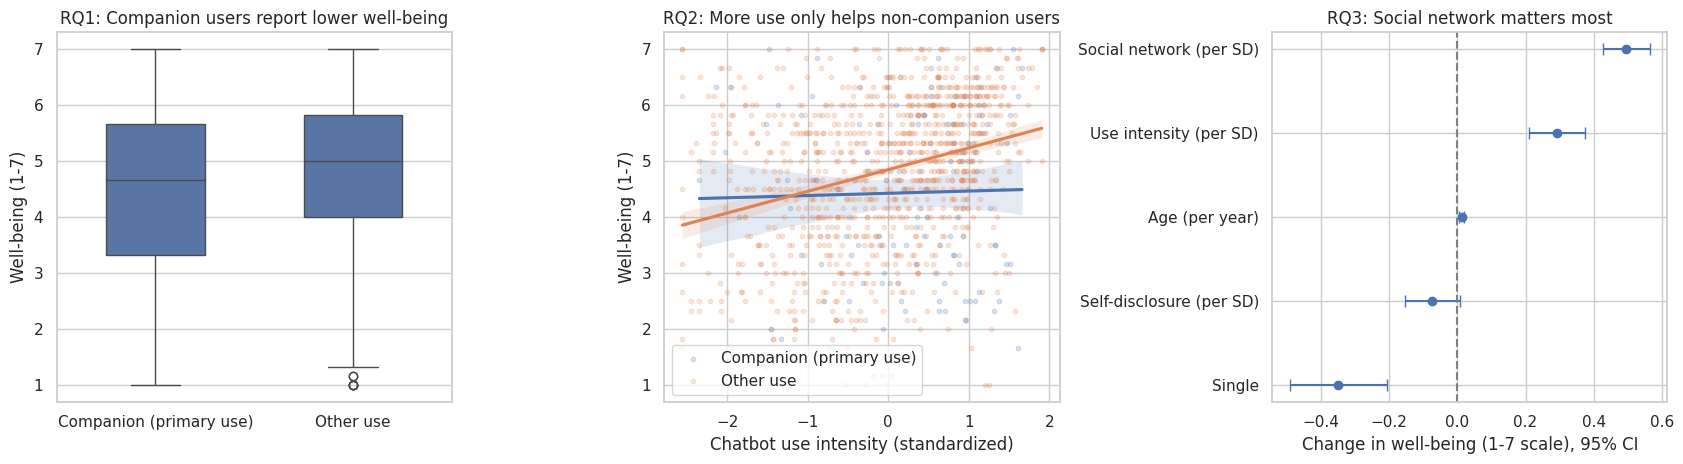

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

order = ["Companion (primary use)", "Other use"]
sns.boxplot(data=df, x="companion_group", y="well_being", order=order, width=0.5, ax=axes[0])
axes[0].set_title("RQ1: Companion users report lower well-being")
axes[0].set_xlabel("")
axes[0].set_ylabel("Well-being (1-7)")

for name, group in df.groupby("companion_group"):
    sns.regplot(data=group, x="intensity", y="well_being", label=name,
                scatter_kws={"alpha": 0.2, "s": 10}, ax=axes[1])
axes[1].set_title("RQ2: More use only helps non-companion users")
axes[1].set_xlabel("Chatbot use intensity (standardized)")
axes[1].set_ylabel("Well-being (1-7)")
axes[1].legend()

ci = model.conf_int()
coefs = pd.DataFrame({"coef": model.params, "low": ci[0], "high": ci[1]}).drop("Intercept")
coefs.index = ["Self-disclosure (per SD)", "Social network (per SD)", "Use intensity (per SD)",
               "Age (per year)", "Single"]
coefs = coefs.sort_values("coef")
axes[2].errorbar(coefs["coef"], coefs.index,
                 xerr=[coefs["coef"] - coefs["low"], coefs["high"] - coefs["coef"]], fmt="o", capsize=4)
axes[2].axvline(0, color="grey", linestyle="--")
axes[2].set_title("RQ3: Social network matters most")
axes[2].set_xlabel("Change in well-being (1-7 scale), 95% CI")

plt.tight_layout()
save_fig("summary_results.png")
plt.show()

## Conclusion
Across 1,131 Character.AI users, the link between AI companions and well-being depends on how the chatbot is used:
1. Users who mainly use the chatbot as a companion report lower well-being than other users (small effect, d = −0.29).
2. More intensive use goes with slightly higher well-being overall (r = 0.25), but not among companion users (r = 0.02).
3. The offline social network is the strongest predictor of well-being (b = 0.50 per SD). Self-disclosure matters only for companion users: those who share more report lower well-being.

Taken together: real-life social connections matter most for well-being, and using a chatbot as a companion, especially with a lot of personal disclosure, goes along with lower well-being.

## Limitations
- One-time survey: we see associations, not cause and effect. People who already feel worse may be the ones who seek out AI companions.
- Only U.S. Character.AI users, a young (median age 27) and self-selected sample.
- Well-being is self-reported.
- The companion group is small (n = 134).